In [1]:
import numpy as np
import bayesflow as bf

import sys
sys.path.append("../")

from src.generative_models import sample_pt_model, sample_mvl_model
from src.context import get_context
from src.priors import sample_pt_prior, sample_mvl_prior

/Users/lschumacher/miniconda3/envs/beef/lib/python3.11/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
context_gen = bf.simulation.ContextGenerator(
    batchable_context_fun=get_context
)

## PT Model

In [3]:
param_names = [r'$\lambda$', r'$\alpha$', r'$\tau$']

PT_PRIOR_MEANS = np.array([1.9, 0.6, 2.5])
PT_PRIOR_STDS = np.array([0.63, 0.34, 1.44])

In [4]:
prior = bf.simulation.Prior(
    batch_prior_fun=sample_pt_prior,
    param_names=param_names
)

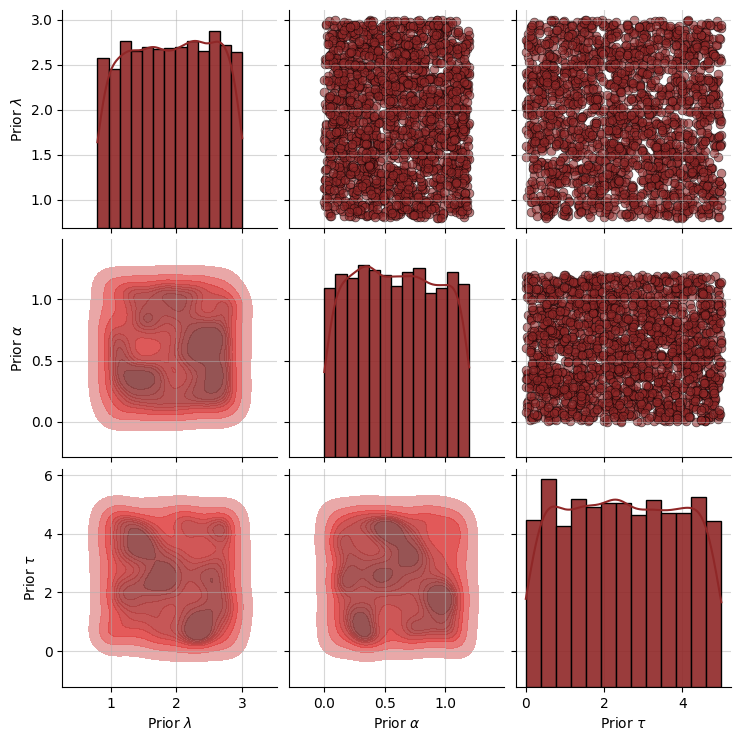

In [5]:
f = prior.plot_prior2d()

In [ ]:
prior.estimate_means_and_stds(10000000)

In [ ]:
simulator = bf.simulation.Simulator(
    simulator_fun=sample_pt_model,
    context_generator=context_gen
)

model = bf.simulation.GenerativeModel(
    prior=prior,
    simulator=simulator,
    name="pt_model"
)

In [ ]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=len(prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [ ]:
def configurator(forward_dict):
    out_dict = {}
    data = forward_dict["sim_data"][:, :, None]
    context = np.array(forward_dict["sim_batchable_context"]) / 100
    out_dict["summary_conditions"] = np.c_[data, context].astype(np.float32)
    params = forward_dict["prior_draws"].astype(np.float32)
    out_dict["parameters"] = (params - PT_PRIOR_MEANS) / PT_PRIOR_STDS
    return out_dict

In [ ]:
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

trainer = bf.trainers.Trainer(
    generative_model=model, 
    amortizer=amortizer, 
    configurator=configurator, 
    checkpoint_path=f"../checkpoints/{model.name}_2",
    max_to_keep=1
)

In [ ]:
history = trainer.train_online(100, 1000, 128)

## MVL model

In [ ]:
param_names = [r'$\b_{var}$', r'$\b_{loss}$', r'$\tau$']

MVL_PRIOR_MEANS = np.array([0.3, 0.3, 0.5])
MVL_PRIOR_STDS = np.array([0.26, 0.26, 0.5])

In [ ]:
prior = bf.simulation.Prior(
    batch_prior_fun=sample_mvl_prior,
    param_names=param_names
)

In [ ]:
simulator = bf.simulation.Simulator(
    simulator_fun=sample_mvl_model,
    context_generator=context_gen
)

model = bf.simulation.GenerativeModel(
    prior=prior,
    simulator=simulator,
    name="mvl_model"
)

In [ ]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=len(prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [ ]:
def configurator(forward_dict):
    out_dict = {}
    data = forward_dict["sim_data"][:, :, None]
    context = np.array(forward_dict["sim_batchable_context"]) / 200
    out_dict["summary_conditions"] = np.c_[data, context].astype(np.float32)
    params = forward_dict["prior_draws"]
    out_dict["parameters"] = ((params - MVL_PRIOR_MEANS) / MVL_PRIOR_STDS).astype(np.float32)
    return out_dict

In [ ]:
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

trainer = bf.trainers.Trainer(
    generative_model=model, 
    amortizer=amortizer, 
    configurator=configurator, 
    checkpoint_path=f"../checkpoints/{model.name}",
    max_to_keep=1
)

In [ ]:
history = trainer.train_online(100, 1000, 128)